# ROSIDS — Final Test Evaluation

This notebook reports the frozen-test results of the three reference classifiers evaluated on ROSIDS:

- Decision Tree
- Random Forest
- XGBoost

The reported aggregate predictive results are **mean ± standard deviation across the three fixed final-model seeds (27, 32, 59)**. The held-out test partition is used only for final evaluation; model selection was completed from validation results before this stage.

The notebook also reports selected configurations, per-seed results, class-level performance, confusion matrices, computational timing, validation-versus-test comparisons, and aggregated feature importance.


## Evaluation protocol

The models evaluated here are the persisted final models produced after the predefined validation procedure. Each selected configuration was refit on the complete ROSIDS training partition for seeds 27, 32, and 59 and then evaluated on the unchanged frozen ROSIDS test partition.

The primary selection metric was Macro F1. The test results below do not perform model selection or hyperparameter tuning.


In [45]:
from typing import cast

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from pipeline.common import load_test_predictions
from reporting.test import (
    CLASSIFIER_ORDER,
    DEFAULT_ARTIFACTS_DIRECTORY,
    DEFAULT_FEATURE_IMPORTANCE_TOP_N,
    METRIC_DISPLAY_NAMES,
    PRIMARY_TEST_METRIC,
    TestExperimentArtifacts,
    TestStatistics,
    compile_dataset_feature_importances,
    compile_test_statistics,
    display_test_confusion_matrices,
    load_test_experiment_artifacts,
    plot_dataset_feature_importance_heatmap,
    plot_dataset_feature_importances,
    plot_metric_comparison,
    plot_per_class_metric_heatmap,
    plot_test_seed_metric,
    prepare_dataset_feature_importance_table,
)

In [46]:
# ============================================================================
# Configuration
# ============================================================================

ARTIFACTS_DIRECTORY = DEFAULT_ARTIFACTS_DIRECTORY
DATASET_NAME = "ROSIDS"

# Confusion matrices and detailed error examples are shown for one explicit,
# reproducible seed. The aggregate tables still use all three seeds.
REPRESENTATIVE_SEED = 27
ERROR_EXAMPLE_COUNT = 5
TOP_CONFUSION_COUNT = 5

## Load and validate the persisted test artifacts


In [47]:
artifacts_by_classifier: dict[str, TestExperimentArtifacts] = {}

for classifier_name in CLASSIFIER_ORDER:
    artifacts_by_classifier[classifier_name] = load_test_experiment_artifacts(
        dataset_name=DATASET_NAME,
        classifier_name=classifier_name,
        artifacts_directory=ARTIFACTS_DIRECTORY,
    )

statistics_by_classifier: dict[str, TestStatistics] = {
    classifier_name: compile_test_statistics(
        artifacts=artifacts_by_classifier[classifier_name],
        include_validation_comparison=True,
    )
    for classifier_name in CLASSIFIER_ORDER
}

## Experiment configuration and evaluation scope


In [48]:
experiment_rows: list[dict[str, object]] = []

for classifier_name in CLASSIFIER_ORDER:
    experiment = artifacts_by_classifier[classifier_name]
    metadata = experiment.metadata

    test_row_count = metadata.get("test_row_count")
    seed_count = metadata.get("seed_count")

    seed_values = tuple(
        sorted(int(seed) for seed in experiment.seed_metrics["seed"].unique())
    )

    experiment_rows.append(
        {
            "Dataset": experiment.dataset_name,
            "Classifier": str(
                statistics_by_classifier[classifier_name]
                .summary_table["Classifier"]
                .iat[0]
            ),
            "Test observations": (
                int(test_row_count) if isinstance(test_row_count, int) else pd.NA
            ),
            "Seeds": (
                int(seed_count) if isinstance(seed_count, int) else len(seed_values)
            ),
            "Seed values": ", ".join(str(seed) for seed in seed_values),
        },
    )

rosids_experiment_table = pd.DataFrame(experiment_rows)

display(rosids_experiment_table)

,Dataset,Classifier,Test observations,Seeds,Seed values
0,ROSIDS,Decision Tree,27337,3,"27, 32, 59"
1,ROSIDS,Random Forest,27337,3,"27, 32, 59"
2,ROSIDS,XGBoost,27337,3,"27, 32, 59"


## Selected configurations


In [49]:
configuration_tables: list[pd.DataFrame] = []

for classifier_name in CLASSIFIER_ORDER:
    statistics = statistics_by_classifier[classifier_name]

    configuration_table = statistics.selected_configuration_table.copy()
    configuration_table.insert(
        0,
        "Classifier",
        str(statistics.summary_table["Classifier"].iat[0]),
    )

    configuration_tables.append(configuration_table)

rosids_selected_configurations = pd.concat(
    configuration_tables, ignore_index=True
).reset_index(drop=True)

display(rosids_selected_configurations)

,Classifier,Configuration ID,criterion,max_depth,min_samples_leaf,min_samples_split,sampler,n_estimators,learning_rate,min_child_weight,subsample
0,Decision Tree,34fdea955c76,entropy,20,1.0,10.0,passthrough,NaN,NaN,NaN,NaN
1,Random Forest,490871c4e714,NaN,20,1.0,5.0,passthrough,200.0,NaN,NaN,NaN
2,XGBoost,17edbfb766e1,NaN,6,NaN,NaN,passthrough,200.0,0.1,1.0,0.8


## Final predictive performance

The main comparison table reports all scalar test metrics using the same frozen test partition and the same three final-model seeds for every classifier.

These values should be interpreted as **mean ± standard deviation across seeds**, not as a single test run.


In [50]:
rosids_test_summary = pd.concat(
    [
        statistics_by_classifier[classifier_name].summary_table
        for classifier_name in CLASSIFIER_ORDER
    ],
    ignore_index=True,
).reset_index(drop=True)

display(rosids_test_summary)

,Dataset,Classifier,Seeds,Accuracy,Precision,Recall,Macro F1,ROC-AUC,PR-AUC,MCC,Balanced Accuracy
0,ROSIDS,Decision Tree,3,0.973479167429 ± 0.000182902293,0.946500313889 ± 0.000595631756,0.946201922930 ± 0.000154223055,0.946315938629 ± 0.000255890723,0.984711562834 ± 0.000065770696,0.944957539619 ± 0.000403436894,0.961339496273 ± 0.000262731401,0.946201922930 ± 0.000154223055
1,ROSIDS,Random Forest,3,0.977893209448 ± 0.000201469457,0.957140718454 ± 0.000557730552,0.953372557079 ± 0.000501608077,0.955134688621 ± 0.000419155610,0.996097032315 ± 0.000042646023,0.971865382327 ± 0.000139321852,0.967766530361 ± 0.000292307171,0.953372557079 ± 0.000501608077
2,ROSIDS,XGBoost,3,0.977210374218 ± 0.000109741376,0.955199069084 ± 0.000442058249,0.952740797465 ± 0.000452281487,0.953881867779 ± 0.000429487849,0.996584804795 ± 0.000041154510,0.973505115854 ± 0.000362544416,0.966773295712 ± 0.000160592671,0.952740797465 ± 0.000452281487


### Primary metric — Macro F1


In [51]:
primary_metric_column = METRIC_DISPLAY_NAMES[PRIMARY_TEST_METRIC]

rosids_primary_metric_summary = rosids_test_summary[
    [
        "Dataset",
        "Classifier",
        "Seeds",
        primary_metric_column,
    ]
].copy()

display(rosids_primary_metric_summary)

,Dataset,Classifier,Seeds,Macro F1
0,ROSIDS,Decision Tree,3,0.946315938629 ± 0.000255890723
1,ROSIDS,Random Forest,3,0.955134688621 ± 0.000419155610
2,ROSIDS,XGBoost,3,0.953881867779 ± 0.000429487849


### Quantified differences in the primary metric

The table below reports pairwise differences between the mean Macro F1 values. It is descriptive only; it does not select or rank a preferred method.


In [52]:
macro_f1_values = {
    str(row["Classifier"]): float(str(row[primary_metric_column]).split(" ± ")[0])
    for _, row in rosids_test_summary.iterrows()
}

comparison_pairs = (
    ("Decision Tree", "Random Forest"),
    ("Decision Tree", "XGBoost"),
    ("Random Forest", "XGBoost"),
)

difference_rows = [
    {
        "Comparison": f"{right} − {left}",
        "Mean Macro F1 difference": macro_f1_values[right] - macro_f1_values[left],
    }
    for left, right in comparison_pairs
]

rosids_macro_f1_differences = pd.DataFrame(difference_rows)

display(rosids_macro_f1_differences)

,Comparison,Mean Macro F1 difference
0,Random Forest − Decision Tree,0.008819
1,XGBoost − Decision Tree,0.007566
2,XGBoost − Random Forest,-0.001253


## Test results by seed

The aggregate table above summarizes the three runs. The following table exposes the individual seed measurements so the variability behind the mean ± standard deviation can be inspected directly.


In [53]:
rosids_seed_metrics = pd.concat(
    [
        statistics_by_classifier[classifier_name].seed_metrics_table
        for classifier_name in CLASSIFIER_ORDER
    ],
    ignore_index=True,
).reset_index(drop=True)

display(rosids_seed_metrics)

,Dataset,Classifier,Seed,Configuration ID,Accuracy,Precision,Recall,Macro F1,ROC-AUC,PR-AUC,MCC,Balanced Accuracy
0,ROSIDS,Decision Tree,27,34fdea955c76,0.973479167429,0.946695086249,0.946308433884,0.946464454891,0.984641808913,0.945020135497,0.961340031861,0.946308433884
1,ROSIDS,Decision Tree,32,34fdea955c76,0.973662069722,0.946974176327,0.946025070070,0.946462898156,0.984720428692,0.945326019925,0.961601959471,0.946025070070
2,ROSIDS,Decision Tree,59,34fdea955c76,0.973296265135,0.945831679090,0.946272264837,0.946020462840,0.984772450896,0.944526463436,0.961076497487,0.946272264837
3,ROSIDS,Random Forest,27,490871c4e714,0.978124885686,0.957763674995,0.953630246941,0.955582122991,0.996054126095,0.971841664444,0.968102391472,0.953630246941
4,ROSIDS,Random Forest,32,490871c4e714,0.977795661558,0.956687793269,0.953692942171,0.955070794117,0.996097557561,0.972015040670,0.967627607872,0.953692942171
5,ROSIDS,Random Forest,59,490871c4e714,0.977759081099,0.956970687097,0.952794482124,0.954751148756,0.996139413289,0.971739441868,0.967569591739,0.952794482124
6,ROSIDS,XGBoost,27,17edbfb766e1,0.977100632842,0.954713837506,0.952236995104,0.953385991130,0.996582935123,0.973620064366,0.966613177861,0.952236995104
7,ROSIDS,XGBoost,32,17edbfb766e1,0.977320115594,0.955304468866,0.953111845318,0.954123515296,0.996626862276,0.973796251097,0.966934359028,0.953111845318
8,ROSIDS,XGBoost,59,17edbfb766e1,0.977210374218,0.955578900879,0.952873551973,0.954136096910,0.996544616986,0.973099032098,0.966772350248,0.952873551973


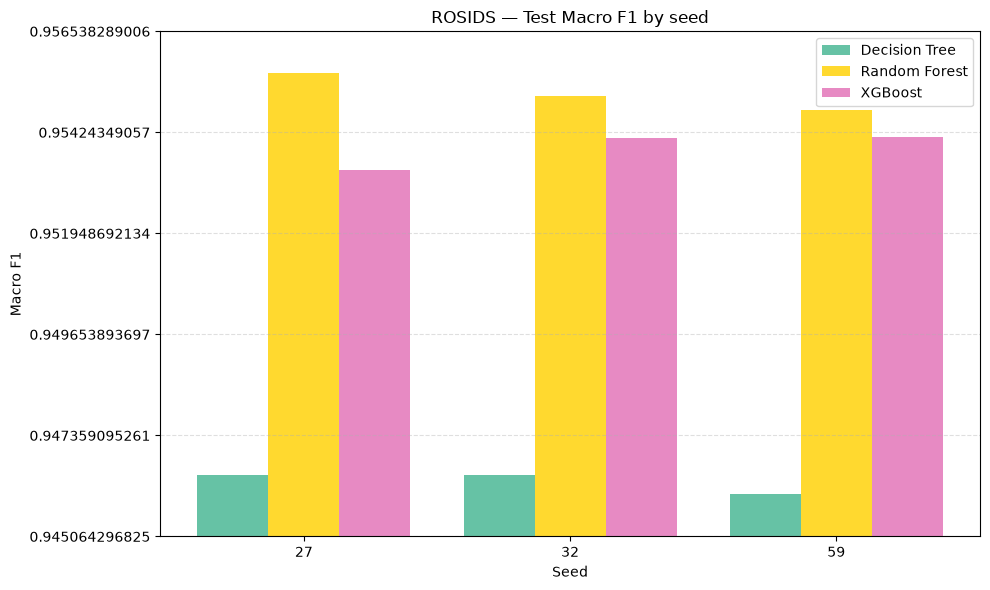

In [54]:
seed_metric_plot_data = pd.concat(
    [
        artifacts_by_classifier[classifier_name].seed_metrics
        for classifier_name in CLASSIFIER_ORDER
    ],
    ignore_index=True,
).reset_index(drop=True)

figure = plot_test_seed_metric(
    seed_metrics=seed_metric_plot_data,
    metric=PRIMARY_TEST_METRIC,
    title=(
        f"{DATASET_NAME} — Test {METRIC_DISPLAY_NAMES[PRIMARY_TEST_METRIC]} by seed"
    ),
)

display(figure)
plt.close(figure)

## Per-class performance

Per-class precision, recall, and F1 are aggregated across seeds. Support is the number of test observations belonging to each class and is constant across seeds and classifiers.

This section identifies classes for which the aggregate metrics may conceal substantially different behaviour.


In [55]:
rosids_per_class_metrics = pd.concat(
    [
        statistics_by_classifier[classifier_name].per_class_metrics_table
        for classifier_name in CLASSIFIER_ORDER
    ],
    ignore_index=True,
).reset_index(drop=True)

display(rosids_per_class_metrics)

,Classifier,Class,Support,Precision,Recall,F1
0,Decision Tree,Benign,12503,0.971047976229 ± 0.000111711479,0.975552534059 ± 0.000488690789,0.973294992859 ± 0.000226521945
1,Decision Tree,DoS,6200,0.999408784181 ± 0.000186061890,0.999677419355 ± 0.000000000000,0.999543077944 ± 0.000093060951
2,Decision Tree,Subflood,6013,0.987984374799 ± 0.000345676497,0.975442097677 ± 0.000096017008,0.981673147092 ± 0.000141427915
3,Decision Tree,UnauthPub,1563,0.908198253546 ± 0.001210000866,0.926210279377 ± 0.000369385969,0.917115655927 ± 0.000755794873
4,Decision Tree,UnauthSub,1058,0.865862180689 ± 0.002075284438,0.854127284184 ± 0.001443785663,0.859952819322 ± 0.000865654307
5,Random Forest,Benign,12503,0.973955887886 ± 0.000202900036,0.981044549308 ± 0.000399904023,0.977487329150 ± 0.000210182319
6,Random Forest,DoS,6200,1.000000000000 ± 0.000000000000,0.999677419355 ± 0.000000000000,0.999838683659 ± 0.000000000000
7,Random Forest,Subflood,6013,0.992515481807 ± 0.000194582806,0.977714950940 ± 0.000166306336,0.985059623419 ± 0.000174202534
8,Random Forest,UnauthPub,1563,0.918018535979 ± 0.001701196264,0.943271486458 ± 0.000738771938,0.930472740582 ± 0.000653778341
9,Random Forest,UnauthSub,1058,0.901213686595 ± 0.001190573387,0.865154379332 ± 0.002728498437,0.882815066295 ± 0.001851954854


In [56]:
# Class support is derived from the persisted per-class test results.
rosids_test_class_support = (
    rosids_per_class_metrics[["Class", "Support"]]
    .drop_duplicates()
    .sort_values("Support", ascending=False, ignore_index=True)
)

display(rosids_test_class_support)

,Class,Support
0,Benign,12503
1,DoS,6200
2,Subflood,6013
3,UnauthPub,1563
4,UnauthSub,1058


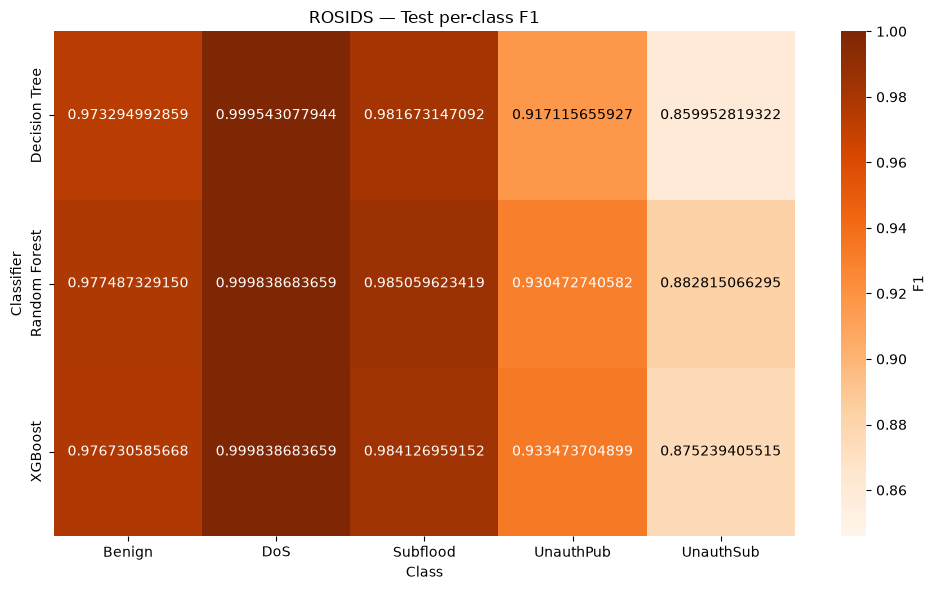

In [57]:
per_class_plot_data = pd.concat(
    [
        artifacts_by_classifier[classifier_name].per_class_metrics
        for classifier_name in CLASSIFIER_ORDER
    ],
    ignore_index=True,
).reset_index(drop=True)

figure = plot_per_class_metric_heatmap(
    per_class_metrics=per_class_plot_data,
    metric="f1",
    title=f"{DATASET_NAME} — Test per-class F1",
)

display(figure)
plt.close(figure)

## Error analysis

Detailed confusion and error examples below use **representative seed 27** explicitly. This keeps the displayed confusion matrices tied to one concrete evaluation, while the preceding tables report the three-seed aggregate results.

For each classifier, the notebook reports the most frequent class confusions and the corresponding class-wise false-positive and false-negative counts.


In [58]:
prediction_tables_by_classifier: dict[str, pd.DataFrame] = {}

for classifier_name in CLASSIFIER_ORDER:
    prediction_table = load_test_predictions(
        artifacts_by_classifier[classifier_name].directory,
    )

    prediction_table["seed"] = pd.to_numeric(
        prediction_table["seed"],
        errors="raise",
    ).astype(int)

    representative_predictions = prediction_table[
        prediction_table["seed"] == REPRESENTATIVE_SEED
    ].copy()

    if representative_predictions.empty:
        raise ValueError(
            f"No persisted predictions were found for seed "
            f"{REPRESENTATIVE_SEED} and classifier {classifier_name!r}."
        )

    prediction_tables_by_classifier[classifier_name] = (
        representative_predictions.reset_index(drop=True)
    )

## Errors


In [59]:
error_summary_rows: list[dict[str, object]] = []
top_confusion_rows: list[dict[str, object]] = []
class_error_rows: list[dict[str, object]] = []
error_example_rows: list[dict[str, object]] = []

for classifier_name in CLASSIFIER_ORDER:
    predictions = prediction_tables_by_classifier[classifier_name]
    display_name = str(
        statistics_by_classifier[classifier_name].summary_table["Classifier"].iat[0]
    )

    actual = predictions["actual_class"].astype(str)
    predicted = predictions["predicted_class"].astype(str)
    misclassified = predictions.loc[actual != predicted].copy()

    error_summary_rows.append(
        {
            "Classifier": display_name,
            "Seed": REPRESENTATIVE_SEED,
            "Misclassified": len(misclassified),
            "Test observations": len(predictions),
            "Error rate": (
                len(misclassified) / len(predictions)
                if len(predictions) > 0
                else float("nan")
            ),
        }
    )

    confusion = pd.crosstab(
        actual,
        predicted,
        dropna=False,
    )

    classes = tuple(
        sorted(set(confusion.index.astype(str)) | set(confusion.columns.astype(str)))
    )
    confusion = confusion.reindex(
        index=classes,
        columns=classes,
        fill_value=0,
    )

    non_diagonal = (
        confusion.reset_index()
        .melt(
            id_vars="actual_class",
            var_name="predicted_class",
            value_name="Count",
        )
        .rename(
            columns={
                "actual_class": "Actual class",
                "predicted_class": "Predicted class",
            }
        )
    )

    non_diagonal = non_diagonal[
        non_diagonal["Actual class"] != non_diagonal["Predicted class"]
    ].copy()

    if not non_diagonal.empty:
        non_diagonal["Count"] = pd.to_numeric(
            non_diagonal["Count"],
            errors="raise",
        ).astype(int)

        non_diagonal["Classifier"] = display_name
        non_diagonal["Seed"] = REPRESENTATIVE_SEED

        non_diagonal = non_diagonal.sort_values(
            "Count",
            ascending=False,
            ignore_index=True,
        ).head(TOP_CONFUSION_COUNT)

        top_confusion_rows.extend(
            {str(key): value for key, value in record.items()}
            for record in non_diagonal.to_dict(orient="records")
        )

    for class_name in classes:
        true_positive_value = confusion.at[class_name, class_name]
        true_positives = int(
            float(
                cast(
                    float,
                    true_positive_value,
                ),
            ),
        )

        false_positives = int(
            confusion[class_name].sum() - true_positives,
        )
        false_negatives = int(
            confusion.loc[class_name].sum() - true_positives,
        )

        class_error_rows.append(
            {
                "Classifier": display_name,
                "Seed": REPRESENTATIVE_SEED,
                "Class": class_name,
                "False positives": false_positives,
                "False negatives": false_negatives,
            }
        )

    if not misclassified.empty:
        example_columns = [
            "row_index",
            "actual_class",
            "predicted_class",
        ]
        examples = misclassified[example_columns].head(ERROR_EXAMPLE_COUNT).copy()
        examples.insert(0, "Classifier", display_name)
        examples.insert(1, "Seed", REPRESENTATIVE_SEED)

        error_example_rows.extend(
            {str(key): value for key, value in record.items()}
            for record in examples.to_dict(orient="records")
        )

rosids_error_summary = pd.DataFrame(error_summary_rows)
rosids_top_confusions = pd.DataFrame(top_confusion_rows)
rosids_class_error_counts = pd.DataFrame(class_error_rows)
rosids_representative_errors = pd.DataFrame(error_example_rows)


In [60]:
display(rosids_error_summary)

,Classifier,Seed,Misclassified,Test observations,Error rate
0,Decision Tree,27,725,27337,0.026521
1,Random Forest,27,598,27337,0.021875
2,XGBoost,27,626,27337,0.022899


In [61]:
display(rosids_top_confusions)

,Actual class,Predicted class,Count,Classifier,Seed
0,Subflood,Benign,142,Decision Tree,27
1,UnauthSub,Benign,138,Decision Tree,27
2,Benign,UnauthPub,133,Decision Tree,27
3,Benign,UnauthSub,104,Decision Tree,27
4,UnauthPub,Benign,81,Decision Tree,27
5,UnauthSub,Benign,133,Random Forest,27
6,Subflood,Benign,129,Random Forest,27
7,Benign,UnauthPub,124,Random Forest,27
8,Benign,UnauthSub,71,Random Forest,27
9,UnauthPub,Benign,64,Random Forest,27


In [62]:
display(rosids_class_error_counts)

,Classifier,Seed,Class,False positives,False negatives
0,Decision Tree,27,Benign,362,307
1,Decision Tree,27,DoS,5,2
2,Decision Tree,27,Subflood,73,147
3,Decision Tree,27,UnauthPub,147,115
4,Decision Tree,27,UnauthSub,138,154
5,Random Forest,27,Benign,327,232
6,Random Forest,27,DoS,0,2
7,Random Forest,27,Subflood,43,133
8,Random Forest,27,UnauthPub,129,90
9,Random Forest,27,UnauthSub,99,141


In [63]:
display(rosids_representative_errors)

,Classifier,Seed,row_index,actual_class,predicted_class
0,Decision Tree,27,121433,UnauthPub,Benign
1,Decision Tree,27,30330,Benign,UnauthSub
2,Decision Tree,27,111556,Benign,UnauthPub
3,Decision Tree,27,113785,Benign,UnauthPub
4,Decision Tree,27,133449,UnauthSub,Benign
5,Random Forest,27,121433,UnauthPub,Benign
6,Random Forest,27,111556,Benign,UnauthPub
7,Random Forest,27,124830,UnauthSub,Subflood
8,Random Forest,27,113785,Benign,UnauthPub
9,Random Forest,27,133449,UnauthSub,Benign


### Confusion matrices

The following figures are deliberately labelled with seed 27 because they are **single-seed diagnostic views**, not three-seed averages.


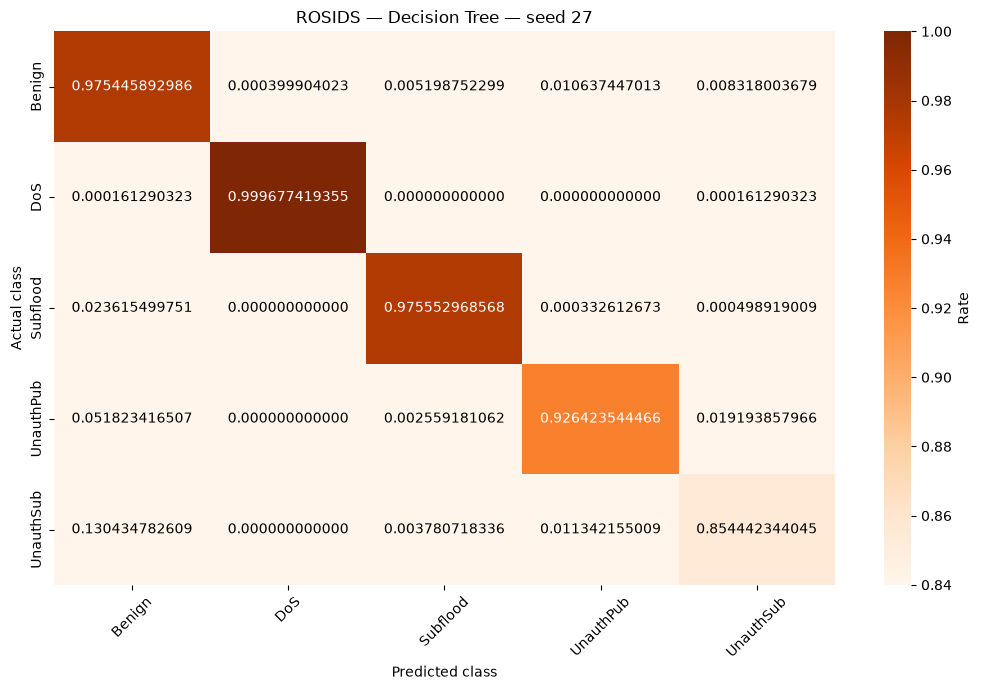

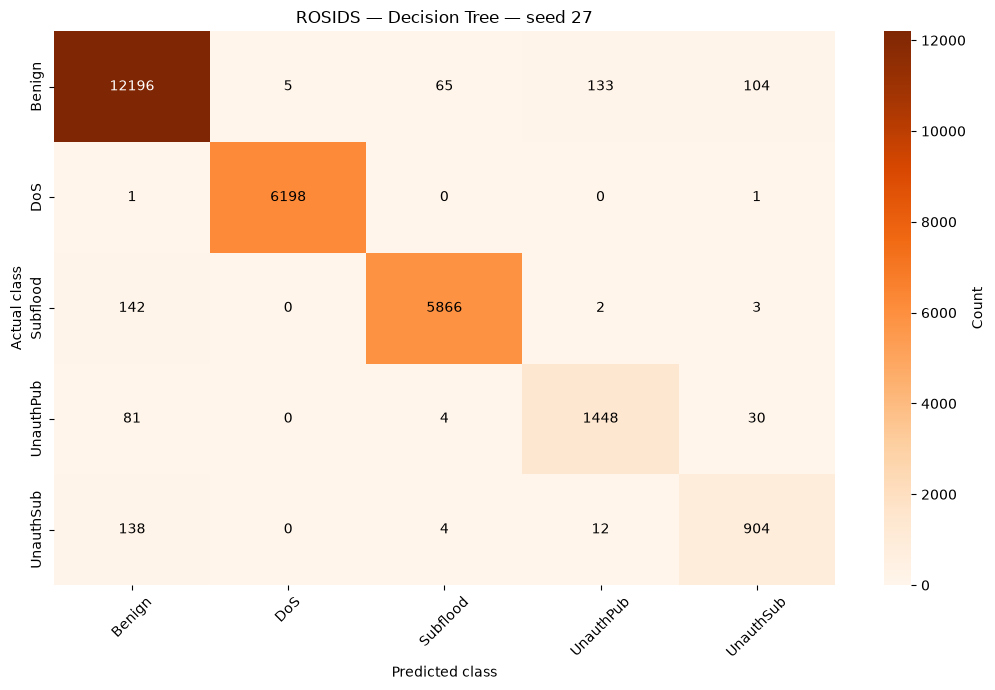

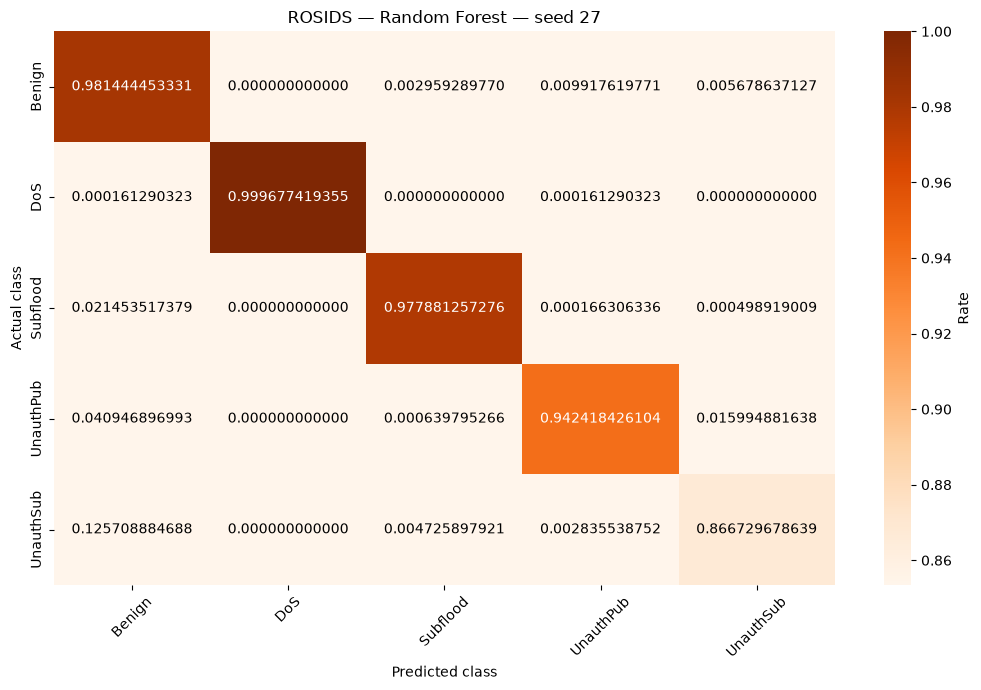

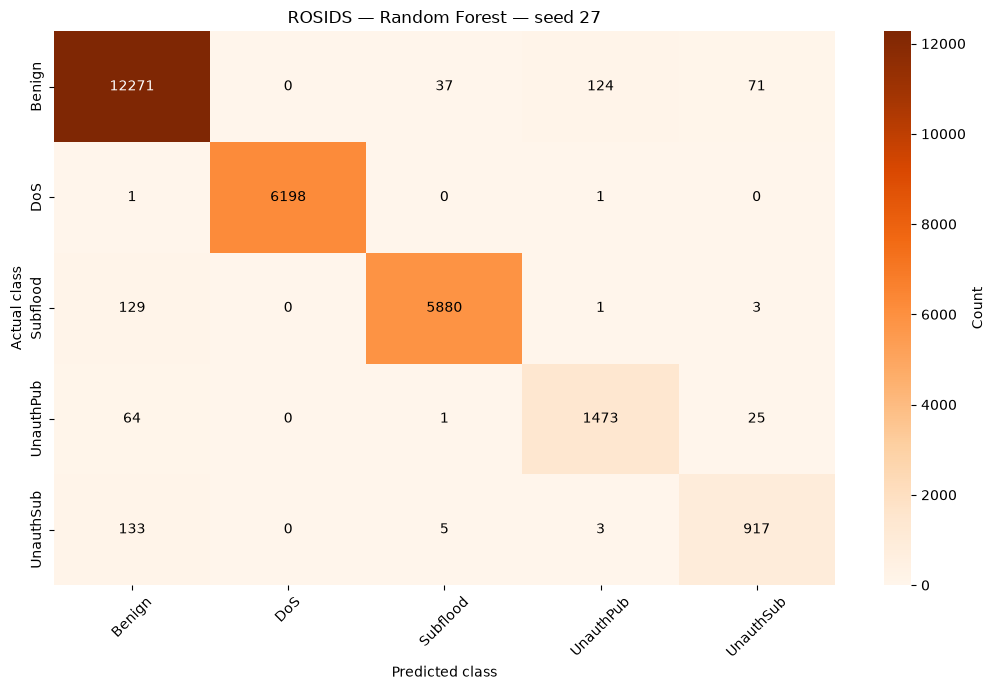

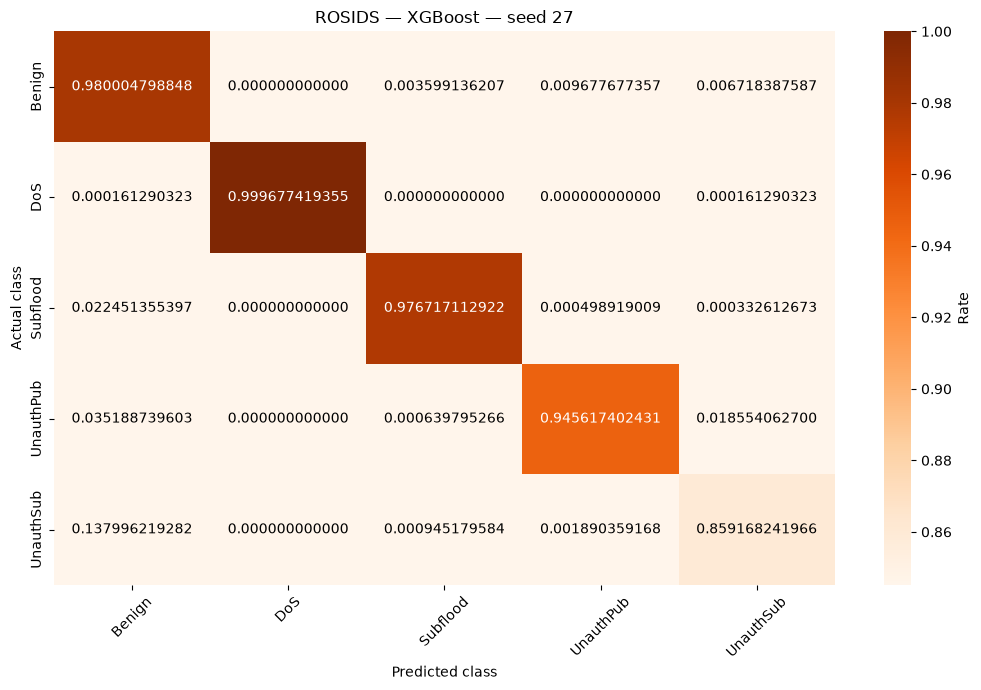

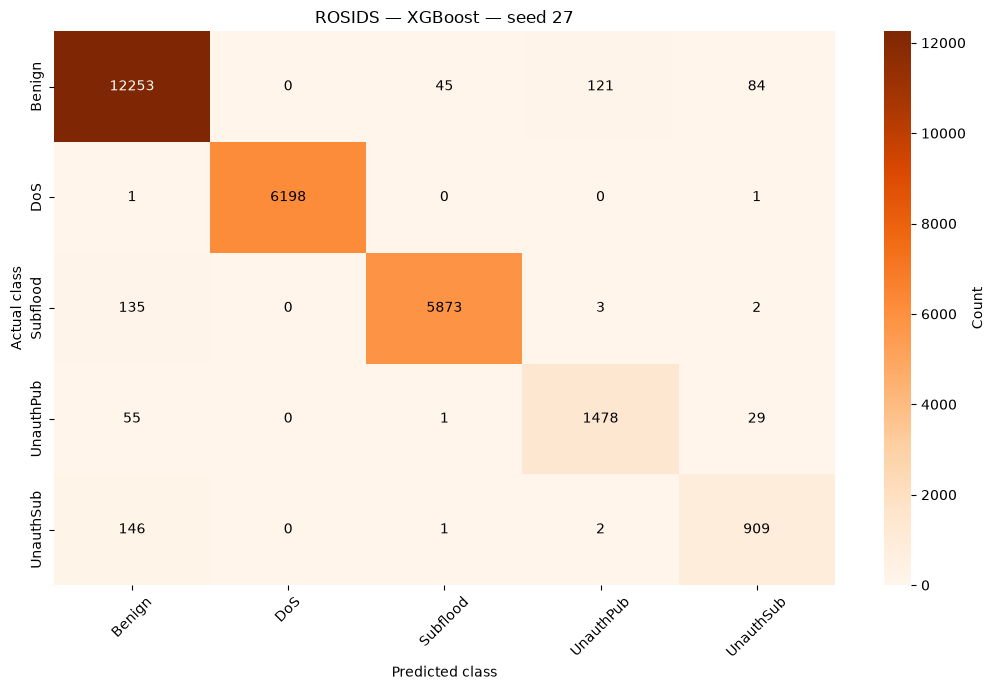

In [64]:
for classifier_name in CLASSIFIER_ORDER:
    experiment = artifacts_by_classifier[classifier_name]

    display_test_confusion_matrices(
        experiment,
        normalized=True,
        seed=REPRESENTATIVE_SEED,
    )

    display_test_confusion_matrices(
        experiment,
        normalized=False,
        seed=REPRESENTATIVE_SEED,
    )

## Validation versus test

The table and figure compare the selected configuration's validation results with its frozen-test performance. Both summaries are calculated across the same seeds (27, 32, 59).

This comparison is descriptive: the test partition remains an evaluation-only dataset.


In [65]:
validation_comparison_tables: list[pd.DataFrame] = []

for classifier_name in CLASSIFIER_ORDER:
    statistics = statistics_by_classifier[classifier_name]
    comparison = statistics.validation_vs_test_table

    if comparison is None:
        continue

    comparison = comparison.copy()
    comparison.insert(
        0,
        "Classifier",
        str(statistics.summary_table["Classifier"].iat[0]),
    )
    validation_comparison_tables.append(comparison)

if validation_comparison_tables:
    rosids_validation_vs_test = pd.concat(
        validation_comparison_tables, ignore_index=True
    ).reset_index(drop=True)
    display(rosids_validation_vs_test)
else:
    rosids_validation_vs_test = None

,Classifier,Metric,validation_mean,validation_std,test_mean,test_std,Validation,Test,Test − validation
0,Decision Tree,Accuracy,0.971353,0.000582,0.973479,0.000183,0.971353404546 ± 0.000582467719,0.973479167429 ± 0.000182902293,0.002126
1,Decision Tree,Precision,0.944314,0.001554,0.946500,0.000596,0.944313784791 ± 0.001553859081,0.946500313889 ± 0.000595631756,0.002187
2,Decision Tree,Recall,0.939972,0.001205,0.946202,0.000154,0.939971670555 ± 0.001204954548,0.946201922930 ± 0.000154223055,0.006230
3,Decision Tree,Macro F1,0.942016,0.001162,0.946316,0.000256,0.942016010987 ± 0.001161963734,0.946315938629 ± 0.000255890723,0.004300
4,Decision Tree,ROC-AUC,0.980585,0.000487,0.984712,0.000066,0.980585123873 ± 0.000487325067,0.984711562834 ± 0.000065770696,0.004126
5,Decision Tree,PR-AUC,0.934272,0.001781,0.944958,0.000403,0.934271569758 ± 0.001781127460,0.944957539619 ± 0.000403436894,0.010686
6,Decision Tree,MCC,0.958225,0.000842,0.961339,0.000263,0.958225027051 ± 0.000841751276,0.961339496273 ± 0.000262731401,0.003114
7,Decision Tree,Balanced Accuracy,0.939972,0.001205,0.946202,0.000154,0.939971670555 ± 0.001204954548,0.946201922930 ± 0.000154223055,0.006230
8,Random Forest,Accuracy,0.976243,0.000164,0.977893,0.000201,0.976243171398 ± 0.000163683955,0.977893209448 ± 0.000201469457,0.001650
9,Random Forest,Precision,0.954911,0.000564,0.957141,0.000558,0.954911100494 ± 0.000564483564,0.957140718454 ± 0.000557730552,0.002230


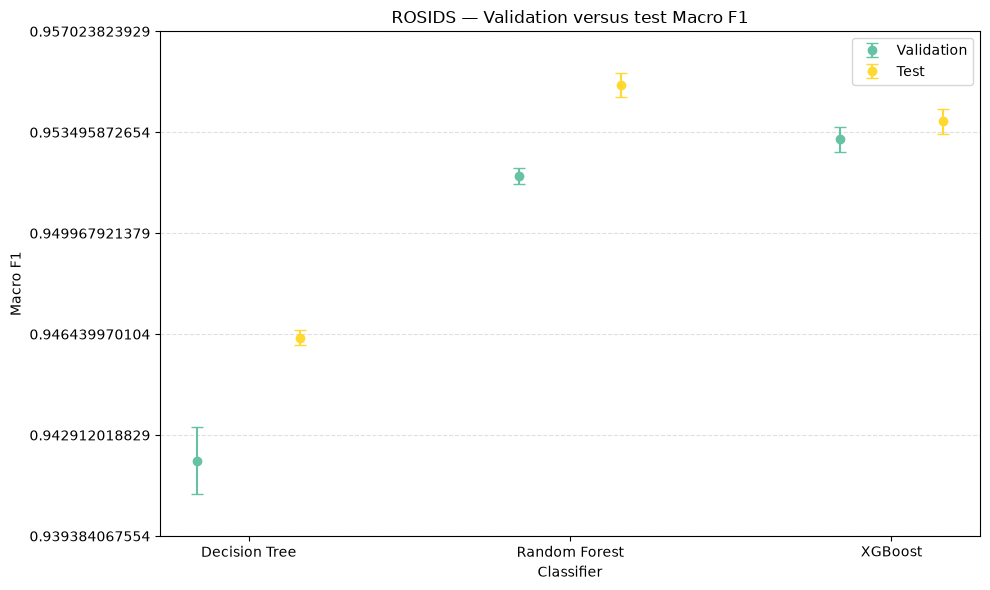

In [66]:
if rosids_validation_vs_test is not None:
    macro_f1_comparison = rosids_validation_vs_test.loc[
        rosids_validation_vs_test["Metric"]
        == METRIC_DISPLAY_NAMES[PRIMARY_TEST_METRIC],
        [
            "Classifier",
            "validation_mean",
            "validation_std",
            "test_mean",
            "test_std",
        ],
    ].copy()

    macro_f1_comparison = macro_f1_comparison.rename(
        columns={"Classifier": "classifier"},
    )

    figure = plot_metric_comparison(
        data_frame=macro_f1_comparison,
        metric=PRIMARY_TEST_METRIC,
        title=(
            f"{DATASET_NAME} — Validation versus test "
            f"{METRIC_DISPLAY_NAMES[PRIMARY_TEST_METRIC]}"
        ),
    )

    display(figure)
    plt.close(figure)

## Computational cost and efficiency

Timing is reported separately from predictive performance.

Training time measures the final selected configuration being fitted on the complete training partition. Inference time measures the persisted model's complete `predict()` + `predict_proba()` execution on the full frozen test partition. Timing excludes model loading, metric calculation, confusion-matrix construction, and artifact writing.


In [67]:
rosids_timing_tables = [
    statistics_by_classifier[classifier_name].timing_table
    for classifier_name in CLASSIFIER_ORDER
]

rosids_timing_summary = pd.concat(rosids_timing_tables, ignore_index=True).reset_index(
    drop=True
)

display(rosids_timing_summary)

,Dataset,Classifier,Seeds,Training time (s),Prediction time (s),Probability time (s),Inference time (s),Inference / 100 samples (s)
0,ROSIDS,Decision Tree,3,2.753159987333 ± 0.008029560588,0.081663100660 ± 0.002274343913,0.079686801667 ± 0.002010417390,0.161349902327 ± 0.004235158477,0.000590225344 ± 0.000015492404
1,ROSIDS,Random Forest,3,24.263409751667 ± 0.225550581016,0.361805250664 ± 0.002218911231,0.360085884332 ± 0.002313450523,0.721891134997 ± 0.004503296437,0.002640710886 ± 0.000016473265
2,ROSIDS,XGBoost,3,19.417738909333 ± 0.364488882131,0.317934649002 ± 0.001108885890,0.315118031668 ± 0.001248814599,0.633052680671 ± 0.002001339086,0.002315735745 ± 0.000007320990


## Feature importance

Feature importance is aggregated over the three final-model seeds and reported at the original-feature level. This section is descriptive and supports interpretation of the reference models; it is not used for model selection.


In [68]:
rosids_feature_importances = compile_dataset_feature_importances(
    dataset_name=DATASET_NAME,
    artifacts_directory=ARTIFACTS_DIRECTORY,
)

rosids_feature_importance_table = prepare_dataset_feature_importance_table(
    rosids_feature_importances,
)

display(rosids_feature_importance_table)

,Feature,Decision Tree,Random Forest,XGBoost
0,destination_port_category,0.405257204514 ± 0.000138350790,0.060035849438 ± 0.007204449530,0.595684756515 ± 0.008210527628
1,initial_backward_window_bytes,0.286300241507 ± 0.000180805610,0.072524207520 ± 0.004081918538,0.068513527513 ± 0.001094292074
2,forward_inter_arrival_time_standard_deviation,0.045554404004 ± 0.000107976247,0.042957640352 ± 0.003791212956,0.062763226529 ± 0.003102335657
3,flow_duration,0.057784521255 ± 0.000132071420,0.023273946766 ± 0.002249815137,0.002829607110 ± 0.000044928148
4,backward_inter_arrival_time_mean,0.054249737670 ± 0.000684053929,0.040467952732 ± 0.002046572004,0.001394953268 ± 0.000109823020
...,...,...,...,...
60,backward_packet_length_minimum,0.000020205001 ± 0.000034996089,0.000610604505 ± 0.000149748950,0.000398328179 ± 0.000031128751
61,idle_standard_deviation,0.000270097611 ± 0.000000006420,0.000110318500 ± 0.000009063580,0.000522387001 ± 0.000063614226
62,active_standard_deviation,0.000022790702 ± 0.000016861584,0.000473571357 ± 0.000264466436,0.000519387288 ± 0.000024233343
63,packet_length_minimum,0.000000000000 ± 0.000000000000,0.000432110296 ± 0.000114704982,0.000000000000 ± 0.000000000000


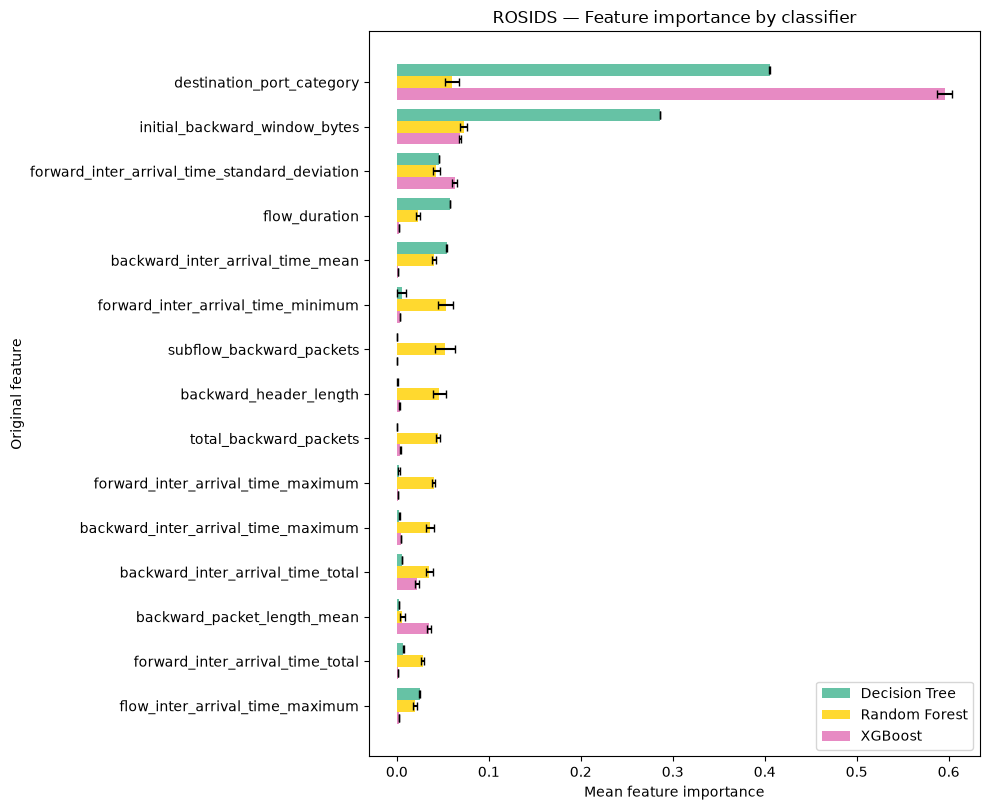

In [69]:
figure = plot_dataset_feature_importances(
    feature_importances=rosids_feature_importances,
    title=f"{DATASET_NAME} — Feature importance by classifier",
    top_n=DEFAULT_FEATURE_IMPORTANCE_TOP_N,
)

display(figure)
plt.close(figure)

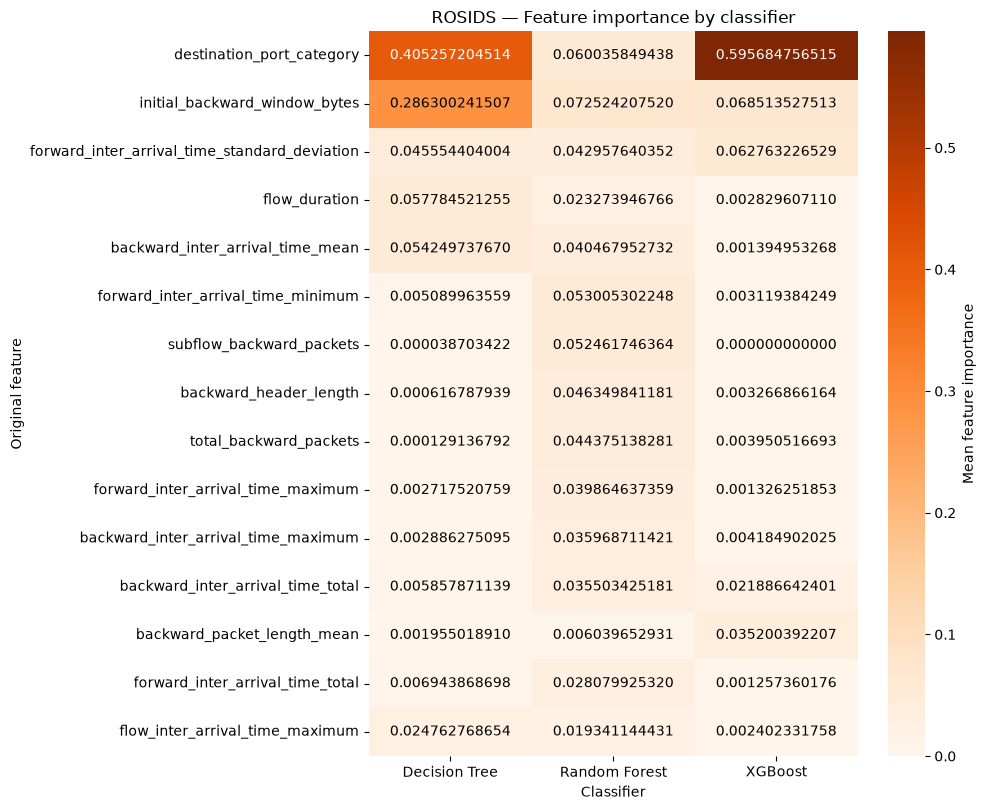

In [70]:
figure = plot_dataset_feature_importance_heatmap(
    feature_importances=rosids_feature_importances,
    title=f"{DATASET_NAME} — Feature importance by classifier",
    top_n=DEFAULT_FEATURE_IMPORTANCE_TOP_N,
)

display(figure)
plt.close(figure)

## Interpretation note

The notebook provides the measurements needed for the Results and Discussion section:

- comparable predictive metrics across the same frozen test partition;
- mean ± standard deviation across the three final-model seeds;
- per-seed measurements;
- class-level performance and class support;
- quantitative error summaries and representative class confusions;
- validation-versus-test comparison;
- final-model training and frozen-test inference timing;
- aggregated feature importance.

Differences observed in these tables are empirical results of the evaluated experimental protocol. Explanations about dataset properties, noise, imbalance, or model complementarity should be presented as interpretations or hypotheses unless directly supported by an additional experiment.
